In [5]:
import numpy as np
import matplotlib.pyplot as plt
import collections
import ROOT as root
import awkward as ak
import uproot
from array import array
import torch
import networkx as nx
from scipy.spatial import Delaunay
from torch_geometric.data import Data, Dataset
import sys
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch.utils.data import ConcatDataset
import os
import glob
import torch.nn.functional as F
from torch_geometric.nn import GCNConv as gcn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import kneighbors_graph

In [6]:
def AddInfo(dbscan_hits, const_hit_array, edep_events):
    event = root.TG4Event()
    edep_events.SetBranchAddress("Event",root.AddressOf(event))
    dbscan_cluster_list = []
    spills_in_file = np.unique(dbscan_hits[:,-4])
    iter_ = 0
    for spill_number in range(1): #spills_in_file:
        spill_level = dbscan_hits[dbscan_hits[:,-4] == spill_number]
        segments_in_spill = np.unique(spill_level[:,-2])
        for segment_number in segments_in_spill:
            time_segment_level = spill_level[spill_level[:,-2] == segment_number]
            clusters_in_segment = np.unique(time_segment_level[:,-1])
            for cluster_number in clusters_in_segment:
                dbscan_cluster_level = time_segment_level[time_segment_level[:,-1] == cluster_number]
                rows = []
                #alright, for each hit can pull the m-nn, m-hn. 
                expected_hits = len(dbscan_cluster_level)
                for i, hit in enumerate(dbscan_cluster_level):
                    #assign refs 
                    m_nn = hit[0]
                    m_hn = hit[1]
                    ref_nn = m_nn
                    ref_hn = m_hn
                
                    #grab the const hit array
                    const_hit_array_nn = const_hit_array[const_hit_array[:,0] == m_nn]
                    const_hit_info = const_hit_array_nn[const_hit_array_nn[:,1] == m_hn]
                
                    #pull the default information. 
                    edep_events.GetEntry(int(m_nn)) #assign the event. Gets called at least once per hit.  
                    #print(f'{m_nn} and {m_hn}')
                    default_hit_segment = (event.SegmentDetectors['volTMS'])[int(m_hn)] #only pull one segment not all.
                    default_trackid = (default_hit_segment.Contrib)[0]
                    default_pdgid = ((event.Trajectories)[default_trackid]).GetPDGCode() #pull only one trajectory and pdgid we are interested in. 

                    #ok now we have the defaults. Two paths:

                    #If our pdgid is != 13, AND we have constituent hits to scan over, then lets scan over them.
                    if (abs(default_pdgid) != 13) and (np.shape(const_hit_info)[0] > 1):
                        #loop over the constituent hit nns, want to limit get entry calls
                        Replaced = False #monitors state, helps us break early or make sure to add our row at the end of no replacement is found. 
                        for constituent_hit_nn in np.unique(const_hit_info[:,2]):
                            #we have to loop over neutrino number since we have instances of merged hits w/ multiple neutrino events. 
                            #check state, and if it has already been replaced, continue no further. 
                            if Replaced == True:
                                break
                            edep_events.GetEntry(int(constituent_hit_nn)) #set the event. 
                            const_nn_sub_array = const_hit_info[const_hit_info[:,2] == constituent_hit_nn ] #grab the constituent hits w/ the desired neutrino number
                            for const_hit in const_nn_sub_array:
                                #another check of state!
                                if Replaced == True:
                                    break
                                
                                const_hit_number = const_hit[-1]
                                const_hit_segment = (event.SegmentDetectors['volTMS'])[int(const_hit_number)] #only pull one segment not all.
                                const_trackid = (const_hit_segment.Contrib)[0]
                                const_pdgid = ((event.Trajectories)[const_trackid]).GetPDGCode() #pull only one trajectory and pdgid we are interested in.
                            
                                #ok, so we've found an instance of a constituent w/ a pdgid of 13! Let's save our row. 
                                if (abs(const_pdgid) == 13):
                                    Replaced = True #set the state. 
                                    new_row = np.array((constituent_hit_nn, const_hit_number, hit[4], hit[2], hit[6], const_trackid, const_pdgid))
                                    rows.append(new_row)
                                    iter_ +=1 

                        #say we have loop over all constituents and found no muons, despite there being constituents, means our Replaced will still be False
                        if (Replaced == False):
                            #if found no replacement despite not being a muon by default, and having constituents, just append the defaults. 
                            new_row = np.array((ref_nn, ref_hn, hit[4], hit[2], hit[6], default_trackid, default_pdgid))
                            rows.append(new_row)
                            iter_ +=1 
    
                    #Else -> Ie, our pdgid == 13, OR our pdgid != 13 but there is only 1 constituent hit, nothing to scan over, just save what we have as default. 
                    else:
                        new_row = np.array((ref_nn, ref_hn, hit[4], hit[2], hit[6], default_trackid, default_pdgid))
                        rows.append(new_row)
                        iter_ +=1

                    if (iter_ % 1000 == 0):
                        print(f'Added info through - {iter_}')

                #add to our running list, now grouped by cluster. 
                infod_hits = len(rows)
                if infod_hits != expected_hits:
                    print(f"Iter - {iter}, Expected {expected_hits}, got {infod_hits} - something is wrong!")
                dbscan_hits_with_info = np.vstack(rows)
                dbscan_cluster_list.append(dbscan_hits_with_info)
                    
    return(dbscan_cluster_list)

In [7]:
def AssignLabels(dbscan_cluster_list, edep_events):
    #initialize 
    event = root.TG4Event()
    edep_events.SetBranchAddress("Event",root.AddressOf(event))
    #separate our cluster by trackid - first step regardless. 
    labeled_slice_list = []
    for chosen_slice in range(len(dbscan_cluster_list)):
        slice_hits = dbscan_cluster_list[chosen_slice]
        trackid_separated = []
        #Yep, should still scan for neutrino number
        for nn in np.unique(slice_hits[:,0]):
            nn_sub_array = slice_hits[slice_hits[:,0] == nn] #pull the hits in our slice w/ a given neutrino #. Should never group trackids across neutrino numbers together. 
            for trackid in np.unique(nn_sub_array[:,-2]): #switch the indexing 
                trackid_sub_array = nn_sub_array[nn_sub_array[:,-2] == trackid]
                trackid_separated.append(trackid_sub_array)
                
        #this statement need to be explicit or it can lead to errors for some reason, break into basic tracks and basic showers
        basic_tracks = []
        basic_showers = []
        for trackid_group in trackid_separated:
            if np.shape(trackid_group)[0] > 4:
                basic_tracks.append(trackid_group)
            if np.shape(trackid_group)[0] <= 4:
                basic_showers.append(trackid_group)

        #create primary track list!
        primary_track_list = []
        for track_group in basic_tracks:
            primary_track_list.append( (int(track_group[0][0]), int(track_group[0][-2])) ) #nn and trackid? 

        advanced_tracks = basic_tracks  
        advanced_showers = []

        #local context, 
        for group in basic_showers:
            nn = group[0][0] #grab neutrino # for group
            trackid = group[0][-2] #grab the trackid for the group
            #now quickly grab the trackids of our primary track groups associated w/this event, for use
            edep_events.GetEntry(int(nn))
            event_trajectories = event.Trajectories #fetch trajectories vector
            group_traj = event_trajectories[int(trackid)] #our root trajectory 
            group_traj_parent = group_traj.GetParentId()
            parent_tuple_reference = (int(nn), int(group_traj_parent))
            added = False
    
            for i, ptref in enumerate(primary_track_list): #i will key which index of the track list to add to. 
                #check first if the parent matches
                if ptref == parent_tuple_reference:
                    #print('found a shower w/ a main track parent')
                    #print(f'{parent_tuple_reference} and {ptref}')
                    advanced_tracks[i] = (np.vstack((basic_tracks[i], group)) )
                    added = True
          
                #if not, check if the grandparent matches, to expand tracks even further. 
                if added ==  False:
                    group_traj_grandparent = event_trajectories[int(group_traj_parent)].GetParentId()
                    grandparent_tuple_reference = (int(nn), int(group_traj_grandparent))
                    if ptref == grandparent_tuple_reference:
                        advanced_tracks[i] = (np.vstack((basic_tracks[i], group)) )
                        added = True
       
                #if not check if the great grandparent matches, expands it even further!! This one may be a bit of a step far. 
        
                if added ==  False:
                    group_traj_great_grandparnet = event_trajectories[int(group_traj_grandparent)].GetParentId()
                    great_grandparent_tuple_reference = (int(nn), int(group_traj_great_grandparnet))
                    if ptref == great_grandparent_tuple_reference:
                        advanced_tracks[i] = (np.vstack((basic_tracks[i], group)) )
                        added = True
    
            if added == False:
                advanced_showers.append(group)

        #lets assign labels and concatenate, track = 0, else = 1, also collapse down to (z,x,PE,label)
        to_stack = []
        if len(advanced_tracks) > 0:
            advanced_tracks_array = np.vstack(advanced_tracks)
            tracks_labeled = np.column_stack(((advanced_tracks_array[:,2], advanced_tracks_array[:,3], advanced_tracks_array[:,4], np.zeros_like(advanced_tracks_array[:,0]))))
            to_stack.append(tracks_labeled)
        if len(advanced_showers) > 0:
            advanced_showers_array = np.vstack(advanced_showers)
            showers_labeled = np.column_stack(((advanced_showers_array[:,2],advanced_showers_array[:,3],advanced_showers_array[:,4], np.ones_like(advanced_showers_array[:,0]))))
            to_stack.append(showers_labeled)
        
        #stack into an array. 
        slice_labeled = np.vstack(to_stack)
        #now add to the list
        labeled_slice_list.append(slice_labeled)

        if (chosen_slice % 100 == 0):
            print(f'Assigned labels through {chosen_slice}')
        
    return(labeled_slice_list)

In [8]:
def RemoveDuplicates(labeled_slices_):
    filtered_slices = []
    for slice_labeled in labeled_slices_:
        zx = slice_labeled[:,[0,1]]
        unique_entries, unique_indices, inverse = np.unique(zx, axis=0, return_index = True, return_inverse = True)
        filtered_ = []
        for group_id in range(len(unique_indices)):
            group_indices = np.where(inverse == group_id)[0] #grabbing indices of the actual locations in the slices labeled array using inverse
            group = slice_labeled[group_indices]
            
            if len(np.unique(group[:,-1])) > 1: #if this is the case we have both tracks and others in a group, grab tracks and append the first. 
                track_instances = group[group[:,-1] == 0]
                #could be multiple instances. Append the first one.
                filtered_.append(track_instances[0])
                
            else: #if this is the case we have only showers or tracks in the group. There may be internal duplicated but we don't care and just grab first instance. 
                filtered_.append(group[0])

        filtered_slices.append((np.vstack(filtered_)))
        
    return(filtered_slices)

In [9]:
def CreateGraphList_FC(graph_points_list_, file_number, occupancy_): #takes an argument of a list of arrays containing the nodes for each cluster properly formatted
    graph_list = [] #list of torch graph objects
    for i, graph_points in enumerate(graph_points_list_):
        dbscan_cluster_object = graph_points #initialize our dbscan cluster.
        #create our graph nodes and features
        node_positions = np.asarray(dbscan_cluster_object[:, 0:2], dtype=float)
        node_features = dbscan_cluster_object[:,0:3]
        #node feature vector (z,x,PE)
        feature_vector = torch.tensor((node_features), dtype = torch.float)
        node_semantic_labels = torch.tensor((dbscan_cluster_object[:,3]), dtype = torch.long)

        #max 1000 (this is kinda just an estimate for high end)
        if np.shape(dbscan_cluster_object)[0] > 1000: #skip it!
            print('Skipped cluster i due to # nodes > 1000, ')
            continue
            
        if np.shape(dbscan_cluster_object)[0] < 3:
            continue

        edges = set() #automatically remove any duplicates (there shouldn't be any but just in case I'm silly)

        #create edge list:
        for i in range(len(node_positions)):
            for j in range(len(node_positions)):
                if (i != j): #no self connected nodes. 
                    edges.add((i,j))               

        edge_index = torch.tensor(list(edges), dtype=torch.long).t().contiguous() #need to transpose since torch expects EdgeIndex like [2, # edges], we produced [# edges, 2] contiguous is a memory flag for gpu opt. 
        #now we can package into a Data object for PyG
        graph_data = Data( x = feature_vector, edge_index = edge_index, y = node_semantic_labels)
        
        #file number along with graph number allow us to traceback to original dbscan cluster from graph later on
        graph_data.file_number = torch.tensor(file_number, dtype=torch.long)
        graph_data.graph_number = torch.tensor(i, dtype=torch.long)
        #adding the occupancy, facilitates quick analysis of accuracy as a function of occupancy.
        graph_data.occupancy = torch.tensor(occupancy_[i], dtype=torch.long)
        
        graph_list.append(graph_data)

    return(graph_list)

In [10]:
DBSCAN_file = np.load('/sdf/data/neutrino/summer25/ktwall/tms_timing/dbscan_clustered/hits_DBSCAN_clustered_epsilon_0.1_2530.npz')
dbscan_hits = DBSCAN_file['first']
occupancy_list = DBSCAN_file['third']

merged_hits_file = np.load('/sdf/data/neutrino/summer25/ktwall/tms_timing/multihit/multihit_detector_sim_lossy_2530.npz')
merged_hits_array = merged_hits_file['first']
n_neutrino_events = merged_hits_file['second']
const_hit_array = merged_hits_file['third']

f = root.TFile.Open("/sdf/data/neutrino/summer25/tanaka/nd-production/run-spill-build/MicroProdN4p1_NDComplex_FHC.spill.full/EDEPSIM_SPILLS/0002000/0002500/MicroProdN4p1_NDComplex_FHC.spill.full.0002530.EDEPSIM_SPILLS.root")
edep_events = f.Get("EDepSimEvents")
# Set the branch address.
event = root.TG4Event()
edep_events.SetBranchAddress("Event",root.AddressOf(event))
print("loaded")

loaded


In [11]:
dbscan_cluster_list_ = AddInfo(dbscan_hits, const_hit_array, edep_events) #adding info
print("Finished assigning hit information!")
print("Starting to format into nodes and assigning labels")
graph_points_list = RemoveDuplicates(AssignLabels(dbscan_cluster_list_, edep_events)) #formatting into graphs w/ the new segmentation. 

#full_file_graph_list = CreateGraphList_FC(graph_points_list, 2530, occupancy_list)

Added info through - 1000
Added info through - 2000
Added info through - 3000
Added info through - 4000
Added info through - 5000
Added info through - 6000
Added info through - 7000
Added info through - 8000
Finished assigning hit information!
Starting to format into nodes and assigning labels
Assigned labels through 0
Assigned labels through 100
Assigned labels through 200


In [32]:
experimental_graph_points = graph_points_list[23]
node_positions = np.asarray(experimental_graph_points[:, 0:2], dtype=float)
knn_graph_matrix = kneighbors_graph(node_positions, n_neighbors=5, mode='connectivity', include_self=False)

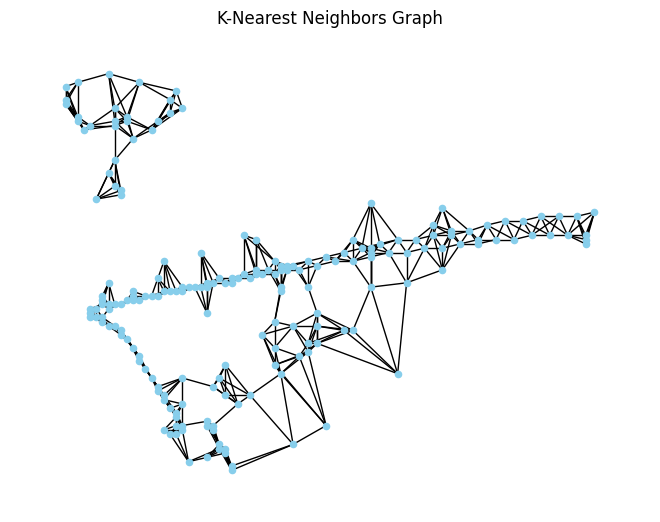

In [29]:
G = nx.from_scipy_sparse_array(knn_graph_matrix)
pos = {i: node_positions[i] for i in range(len(node_positions))} # Use original coordinates for plotting
nx.draw(G, pos, with_labels=False, node_color='skyblue', node_size=20, font_size=10, font_weight='bold')
plt.title("K-Nearest Neighbors Graph")
plt.show()

In [30]:
knn_graph_matrix.toarray()

array([[0., 1., 1., ..., 0., 0., 0.],
       [1., 0., 1., ..., 0., 0., 0.],
       [1., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 1.],
       [0., 0., 0., ..., 1., 0., 1.],
       [0., 0., 0., ..., 1., 1., 0.]])